In [83]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt

from usecases.utils.test_nb_functions import plot_multiple_responses, find_multipliers

## Чтение данных из csv-файлов

Директория с файлами и имена.

In [84]:
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")
# *.dat file first!
sample_file_name_list = [
    "G_U_PI_300_AP.dat",
    "G_U_PI_300_DP.csv"
]
# K_A / K_B.
scaler_list = [
    (2047/5.5) / (4095),
    (2047/5.5) / (4095)
]

data_list = []

delim_list = [None, ',']
for sample_file_name, delim in zip(sample_file_name_list, delim_list):    
    data_list.append(np.loadtxt(sample_dir / sample_file_name, delimiter=delim, skiprows=1).T)

for data, scaler in zip(data_list, scaler_list):
    data[1,:] += 20 * np.log10(scaler)

Проверка частот.

In [85]:
fd = 1e5
err_rel_ref = 1e-3

Nmin, Nmax = [60, 1214]

fmin, fmax = [10, 49e3]
K = 300

freq = np.logspace(np.log10(fmin), np.log10(fmax), K)
freq_approx = np.empty(K, dtype=float)

for idx, f in enumerate(freq):
    (N, M, L), debug_info = find_multipliers(fz=f, fd=fd, err_rel_ref=err_rel_ref, Nmin=Nmin, Nmax=Nmax)
    print(f"N: {N}, M: {M}, L: {L} | fz: {f:.3f}, fz_approx: {debug_info[0]:.3f}, {debug_info[-1]}")
    freq_approx[idx] = debug_info[0]

N: 60, M: 500, L: 3 | fz: 10.000, fz_approx: 10.000, True
N: 60, M: 162, L: 1 | fz: 10.288, fz_approx: 10.288, True
N: 60, M: 315, L: 2 | fz: 10.585, fz_approx: 10.582, True
N: 60, M: 153, L: 1 | fz: 10.890, fz_approx: 10.893, True
N: 60, M: 744, L: 5 | fz: 11.204, fz_approx: 11.201, True
N: 60, M: 434, L: 3 | fz: 11.527, fz_approx: 11.521, True
N: 60, M: 422, L: 3 | fz: 11.859, fz_approx: 11.848, True
N: 60, M: 410, L: 3 | fz: 12.201, fz_approx: 12.195, True
N: 60, M: 664, L: 5 | fz: 12.553, fz_approx: 12.550, True
N: 60, M: 129, L: 1 | fz: 12.914, fz_approx: 12.920, True
N: 60, M: 251, L: 2 | fz: 13.287, fz_approx: 13.280, True
N: 60, M: 122, L: 1 | fz: 13.670, fz_approx: 13.661, True
N: 60, M: 593, L: 5 | fz: 14.064, fz_approx: 14.053, True
N: 60, M: 461, L: 4 | fz: 14.469, fz_approx: 14.461, True
N: 60, M: 112, L: 1 | fz: 14.886, fz_approx: 14.881, True
N: 60, M: 653, L: 6 | fz: 15.315, fz_approx: 15.314, True
N: 60, M: 529, L: 5 | fz: 15.757, fz_approx: 15.753, True
N: 60, M: 617,

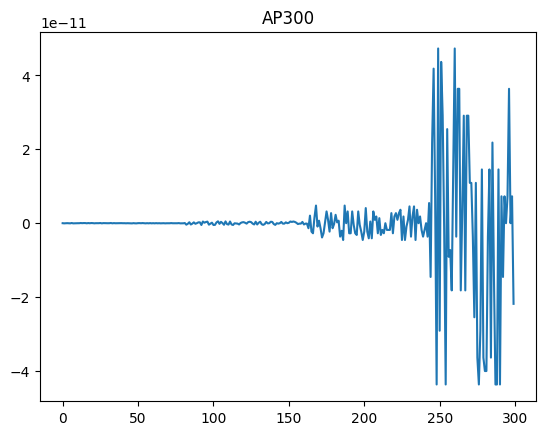

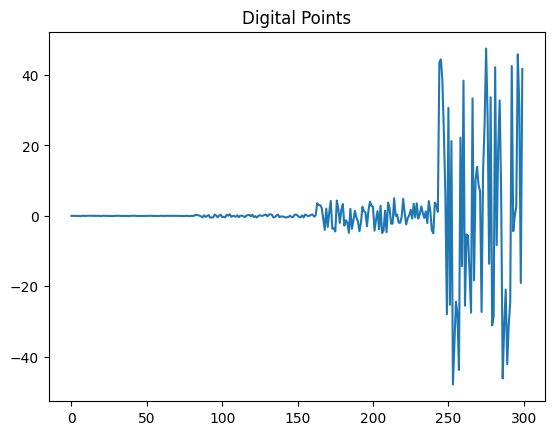

In [86]:
plt.plot(data_list[0][0, :] - freq)
plt.title("AP300")
plt.show()

plt.plot(data_list[1][0, :] - freq_approx)
plt.title("Digital Points")
plt.show()

## Визуализация

In [87]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

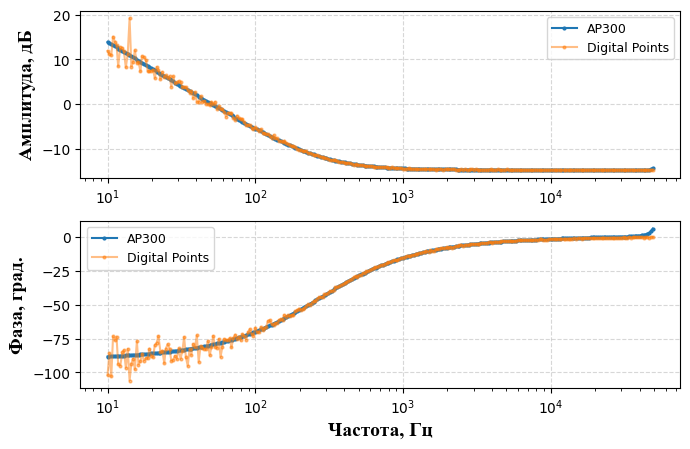

In [88]:
plot_multiple_responses(
    plot_config=PLOT_CONFIG,
    data_list=data_list,
    legend=["AP300", "Digital Points"],
    save_path='usecases/test_samples/experiments_13_May_2026/pdf/G_U_PI.pdf'
    )

In [89]:
def compute_relative_mse(
    ref_input: np.ndarray,
    input_arr: np.ndarray,
    Nmax: int = None,
    eps: float = 1e-12
) -> float:
    """
    Interpolates `input_arr` to the x-coordinates of `ref_input`.
    
    Parameters:
        ref_input : np.ndarray, shape (2, N_ref)
                    ref_input[0] = reference x-coordinates (e.g., frequencies)
                    ref_input[1] = reference y-coordinates (e.g., magnitudes)
        input_arr : np.ndarray, shape (2, N_in)
                    input_arr[0] = source x-coordinates
                    input_arr[1] = source y-coordinates
        Nmax      : int, optional
                    Number of points to use from the start. If None or <=0, uses all data.
        eps       : float, threshold to avoid division by near-zero sums
                    
    Returns:
        mse : float, mean squared relative error
    """
    if ref_input.shape[0] != 2 or input_arr.shape[0] != 2:
        raise ValueError("Both inputs must be of shape (2, N)")
        
    idx = slice(None, Nmax) if Nmax is not None and Nmax > 0 else slice(None)
    
    x_ref = ref_input[0, idx]
    y_ref = ref_input[1, idx]
    x_in  = input_arr[0, idx]
    y_in  = input_arr[1, idx]
    
    # Linear interpolation of input y-values onto reference x-coordinates
    y_interp = np.interp(x_ref, x_in, y_in)
    
    # Symmetric relative difference: (y1 - y2) / ((y1 + y2) / 2)
    sum_y = y_ref + y_interp
    diff_y = y_ref - y_interp
    
    # Apply epsilon condition: term = 0 if (y1 + y2) < eps
    mask = np.abs(sum_y) < eps  
    rel_diff = np.where(mask, 0.0, diff_y / (sum_y / 2.0))
    rel_diff_sq = rel_diff**2
    
    return float(np.mean(rel_diff_sq))

In [90]:
ref_input = data_list[1][:2,:]
input_arr = data_list[0][:2,:]

res = compute_relative_mse(
    ref_input=ref_input,
    input_arr=input_arr,
    Nmax = 300
    )
print(res)
print(res**0.5)

56.30220122140528
7.50347927440366


In [91]:
Uout = 48
Pout_nom = 120
Uin = np.array([24, 36])
R = 40#Pout_nom/Uout * 2 # * np.array([1, 2])
L = 136e-6
C = 4 * 100e-6
ESR = 87e-3 / 4

Le = (Uout / Uin)**2 * L

w_c = 1 / (R*C)
w_ESR = 1 / (ESR*C)
w_RHP = R / Le

'''
fmin = 10
fmax = 50e3
N = 512
freq = np.logspace(np.log10(fmin),np.log10(fmax), N)
'''
freq = data_list[0][0,:]

s = 1j * freq * 2 * np.pi
gain_complex = Uin[0] / Uout * R/2 * (1 - s/w_RHP[0]) * (1 + s/w_ESR) / (1 + s/(2*w_c))# * np.exp(-s/100e3/2)

data = np.array([
    freq,
    20*np.log10(np.abs(gain_complex)),
    180 / np.pi * np.unwrap(np.angle(gain_complex))
])

data_list.append(data)


if interp_flag:
    data_list_interp = []
    for data in data_list:
        freq = data[0,:]
        mag_ph = np.array([data[1,:], data[2,:]])

        freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
        mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
        data_interp = np.vstack((freq_log, mag_ph_interp))
        data_list_interp.append(data_interp)
    data_list = data_list_interp.copy()

NameError: name 'interp_flag' is not defined